In [1]:
# Import các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ẩn các thông báo lỗi
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load dataset
df = pd.read_excel('Global Superstore.xls')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,2012-07-31,2012-07-31,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,2013-02-05,2013-02-07,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,2013-10-17,2013-10-18,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,2013-01-28,2013-01-30,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,2013-11-05,2013-11-06,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


---

### Câu 1

In [3]:
# Lọc các dòng thuộc Turkey
turkey_df = df[df['Country'] == 'Turkey']

In [4]:
# Tính toán tỷ lệ dữ liệu
data_ratio = (turkey_df.shape[0] / df.shape[0]) * 100

In [5]:
print('Tổng số bản ghi:', df.shape[0],
      '\nSố bản ghi:', turkey_df.shape[0],
      '\nTỷ lệ dữ liệu:', round(data_ratio, 2), '%')

Tổng số bản ghi: 51290 
Số bản ghi: 1378 
Tỷ lệ dữ liệu: 2.69 %


In [6]:
# Tiền xử lý và chuẩn hóa dữ liệu
def clean_and_standardize(df):

    df['Order Date'], df['Ship Date'] = pd.to_datetime(df['Order Date']), pd.to_datetime(df['Ship Date']) # Chỉnh lại kiểu dữ liệu ngày cho cột Order Date và Ship Date

    drop_duplicated = df.drop_duplicates() # xóa các hàng có giá trị trùng lập
    check_duplicated = drop_duplicated.duplicated().sum() # kiểm tra lại xem còn hàng trùng lập hay không
    print('Số bản ghi trùng lập sau khi xử lí:', check_duplicated)

    droped_nan_df = turkey_df.drop(columns = 'Postal Code') # Xóa cột Postal code không cần thiết
    sumarize_nan = droped_nan_df.isnull().sum() # Đếm các cột có hàng thiếu giá trị
    print('Giá trị thiếu trong từng cột sau khi xử lí:\n', sumarize_nan)

    for col in droped_nan_df.columns.to_list():
        if droped_nan_df[col].dtypes == 'float64': # đổi kiểu dữ liệu thành float
            droped_nan_df[col] = round(droped_nan_df[col], 2)

    return droped_nan_df

In [7]:
# Xử lý dữ liệu
cleaned_df = clean_and_standardize(turkey_df)

Số bản ghi trùng lập sau khi xử lí: 0
Giá trị thiếu trong từng cột sau khi xử lí:
 Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
City              0
State             0
Country           0
Market            0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
Shipping Cost     0
Order Priority    0
dtype: int64


In [8]:
# Tạo ra cột thời gian xử lý đơn hàng
def create_features(df):
    df['Processing Time'] = (df['Ship Date'] - df['Order Date']).dt.days
    return df

turkey_df = create_features(cleaned_df)

---

### Câu 2

In [9]:
# Phân tích tổng quan thị trường
def analyze_market_overview(df):

    total_order = len(df['Order ID']) # tổng số lượng đơn hàng
    total_customer = len(df['Customer ID'].unique()) # đếm số lượng khách hàng
    total_product = len(df['Product ID'].unique()) # đếm số lượng sản phẩm
    total_sales = round(df['Sales'].sum(), 2) # tổng số doanh thu
    total_profit = round(df['Profit'].sum(), 2) # tổng sổ lợi nhuận
    avg_process_time = round(np.mean(df['Processing Time']), 2) # thời gian xử lý đơn hàng trung bình

    keys_list = ['Tổng số đơn hàng', 'Tổng số doanh số', 'Tổng số lợi nhuận', 'Số lượng khách hàng', 'Số lượng sản phẩm', 'Thời gian xử lí đơn hàng trung bình']
    values_list = [total_order, total_sales, total_profit, total_customer, total_product, avg_process_time]
    sumarize_df = pd.DataFrame({'Hệ số' : keys_list, 'Giá trị' : values_list}) # tạo ra dataframe

    return sumarize_df

overview = analyze_market_overview(turkey_df)
print('Tổng quang thị trường Thỗ Nhĩ Kỳ')
print(overview)

Tổng quang thị trường Thỗ Nhĩ Kỳ
                                 Hệ số    Giá trị
0                     Tổng số đơn hàng    1378.00
1                     Tổng số doanh số  108507.90
2                    Tổng số lợi nhuận  -98447.28
3                  Số lượng khách hàng     463.00
4                    Số lượng sản phẩm     909.00
5  Thời gian xử lí đơn hàng trung bình       3.96


In [10]:
# Tạo ra cột Tỉ lệ lợi nhuận
turkey_df['Profit Ratio'] = (turkey_df['Profit'] / turkey_df['Sales']) * 100

In [11]:
# Phân tích theo hệ số category
def analyze_business_category_metrics(df):

    sum_df = df.groupby('Category')[['Sales', 'Profit', 'Quantity']].sum() # tổng số doanh thu, lợi nhuận và số lượng
    avg_df = round(df.groupby('Category')['Profit Ratio'].mean(), 2) # lợi nhuận trung bình
    concatenate_df = pd.concat([sum_df, avg_df], axis = 1) # ghép 2 cái trên lại
    return concatenate_df

In [12]:
print('Phân tích theo category:')
category_analysis = analyze_business_category_metrics(turkey_df)
print(category_analysis)

Phân tích theo category:
                    Sales    Profit  Quantity  Profit Ratio
Category                                                   
Furniture        34922.43 -30324.18       503        -87.34
Office Supplies  36468.09 -33550.95      1929        -87.60
Technology       37117.38 -34572.15       592        -91.62


In [13]:
# Phân tích hệ số segment
def analyze_business_segment_metrics(df):

    sum_df = df.groupby('Segment')[['Sales', 'Profit']].sum() # tổng số doanh thu và lợi nhuận
    id_df = df.groupby('Segment')['Customer ID'].nunique() # đếm các đơn hàng
    concatenate_df = pd.concat([sum_df, id_df], axis = 1) # ghép 2 cái trên lại
    return concatenate_df

In [14]:
print('Phân tích theo segment:')
segment_analysis = analyze_business_segment_metrics(turkey_df)
print(segment_analysis)

Phân tích theo segment:
                Sales    Profit  Customer ID
Segment                                     
Consumer     50972.82 -46518.81          239
Corporate    34773.33 -31666.74          138
Home Office  22761.75 -20261.73           86


In [15]:
# Phân tích theo tháng
def analyze_business_by_month(df):
    
    new_df = df.copy()
    new_df['Order Date'] = new_df['Order Date'].dt.month # lọc từ ngày tháng năm thành tháng
    sum_df = new_df.groupby('Order Date')[['Sales', 'Quantity']].sum() # tổng số doanh thu và số lượng
    id_df = new_df.groupby('Order Date')['Order ID'].nunique() # đếm các đơn hàng
    concatenate_df = pd.concat([sum_df, id_df], axis = 1) # ghép 2 cái trên lại
    return concatenate_df

In [16]:
print('Thống kê theo tháng:')
month_analysis = analyze_business_by_month(turkey_df)
print(month_analysis)

Thống kê theo tháng:
               Sales  Quantity  Order ID
Order Date                              
1            5872.03       153        37
2            5145.25       174        40
3            5430.30       138        39
4            3548.49       153        39
5            7241.92       187        44
6           15541.73       449        95
7            7645.67       197        42
8           12135.07       327        72
9           16029.96       355        83
10           8285.98       170        35
11           9497.46       375        62
12          12134.04       346        88


---

### Câu 3

In [17]:
# Vẽ đồ thị đường theo thời gian
def time_series_plot(df, column, label):

    # Lọc ra data theo từng tháng
    monthly_df = df[['Order Date', column]]
    monthly_df['Order Date'] = monthly_df['Order Date'].dt.to_period('M')  
    monthly_df = monthly_df.groupby('Order Date')[column].sum().reset_index()
    monthly_df['Order Date'] = monthly_df['Order Date'].astype(str)

    # Lọc ra data theo từng quý
    quarterly_df = df[['Order Date', column]]
    quarterly_df['Order Date'] = quarterly_df['Order Date'].dt.to_period('Q')  
    quarterly_df = quarterly_df.groupby('Order Date')[column].sum().reset_index()
    quarterly_df['Order Date'] = quarterly_df['Order Date'].astype(str)
    quarterly_df['Order Date'] = pd.to_datetime(quarterly_df['Order Date'].astype(str).apply(lambda x: pd.Period(x, freq='Q-DEC').end_time))
    quarterly_df['Order Date'] = quarterly_df['Order Date'].dt.to_period('M')
    quarterly_df['Order Date'] = quarterly_df['Order Date'].astype(str)

    # Tạo một biểu đồ có định dạng x = 20, y = 5
    plt.figure(figsize=(20,5))

    # Vẽ đường data theo tháng
    sns.lineplot(data = monthly_df, x = 'Order Date', y = column, label = label + ' hàng tháng', markers = 's')
    # Vẽ đường data theo quý
    sns.lineplot(data = quarterly_df, x = 'Order Date', y = column, label = label + ' hàng quý', marker = "s")

    # Trang trí biểu đồ
    plt.xlabel('Thời gian')
    plt.ylabel(label)
    plt.title('Xu hướng ' + label + ' theo thời gian')
    plt.xticks(rotation = 45)
    plt.legend(title = 'Gộp dữ liệu')
    plt.grid(True)
    plt.tight_layout()

    # Show biểu đồ
    plt.show()

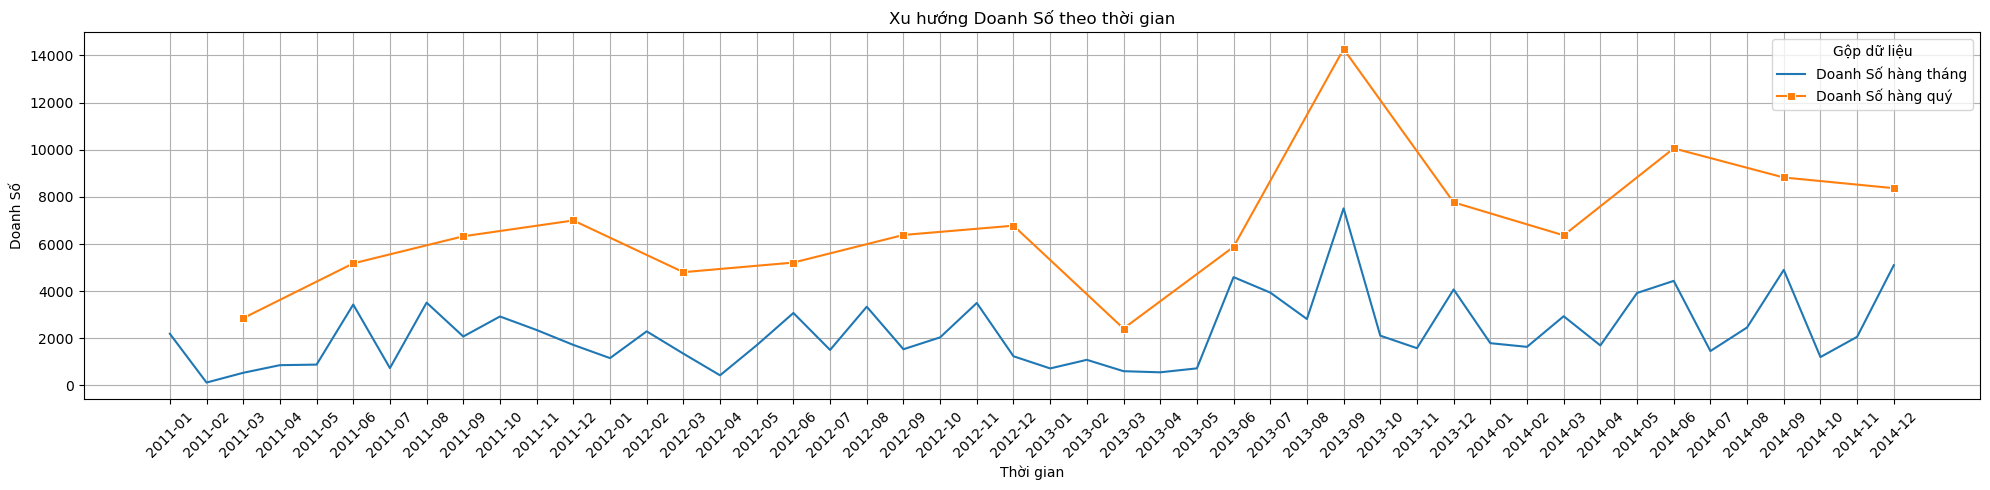

In [18]:
# Vẽ biểu đồ doanh thu 
time_series_plot(turkey_df, 'Sales', 'Doanh Số')

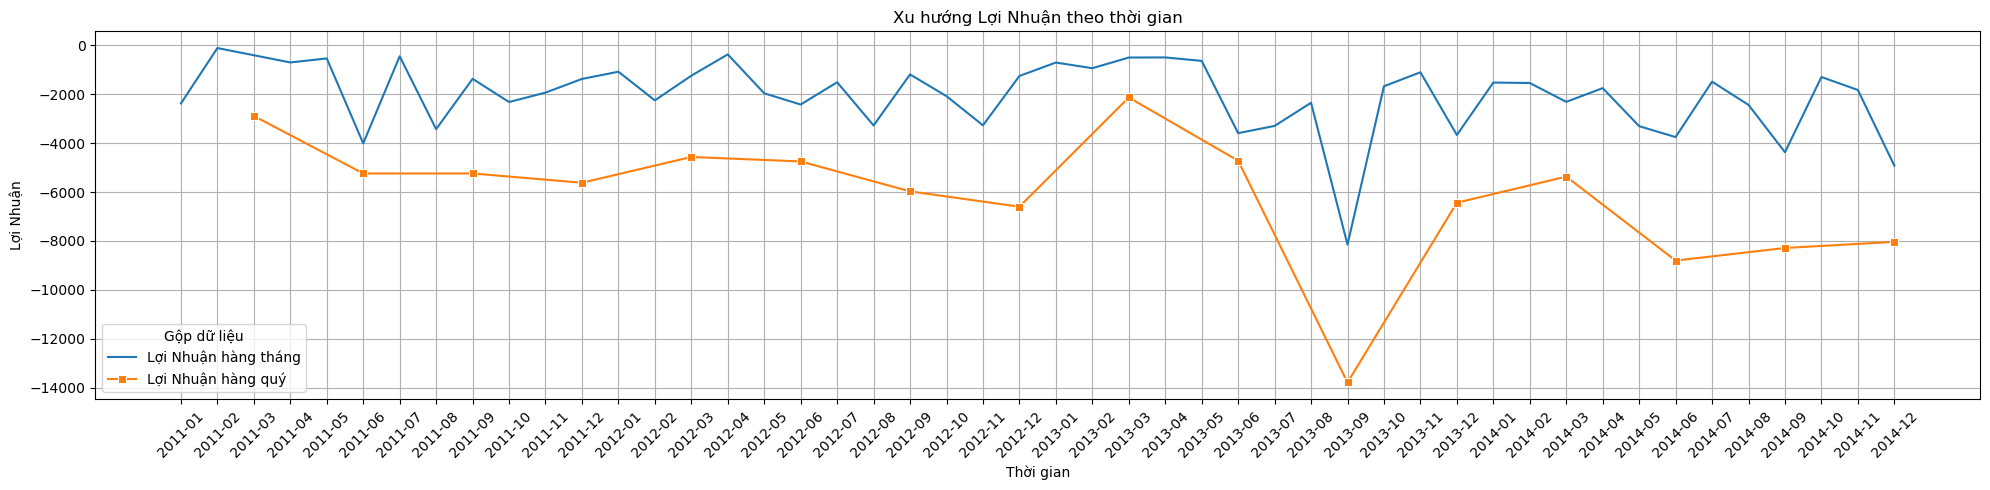

In [19]:
# Vẽ biểu đồ lợi nhuận
time_series_plot(turkey_df, 'Profit', 'Lợi Nhuận')

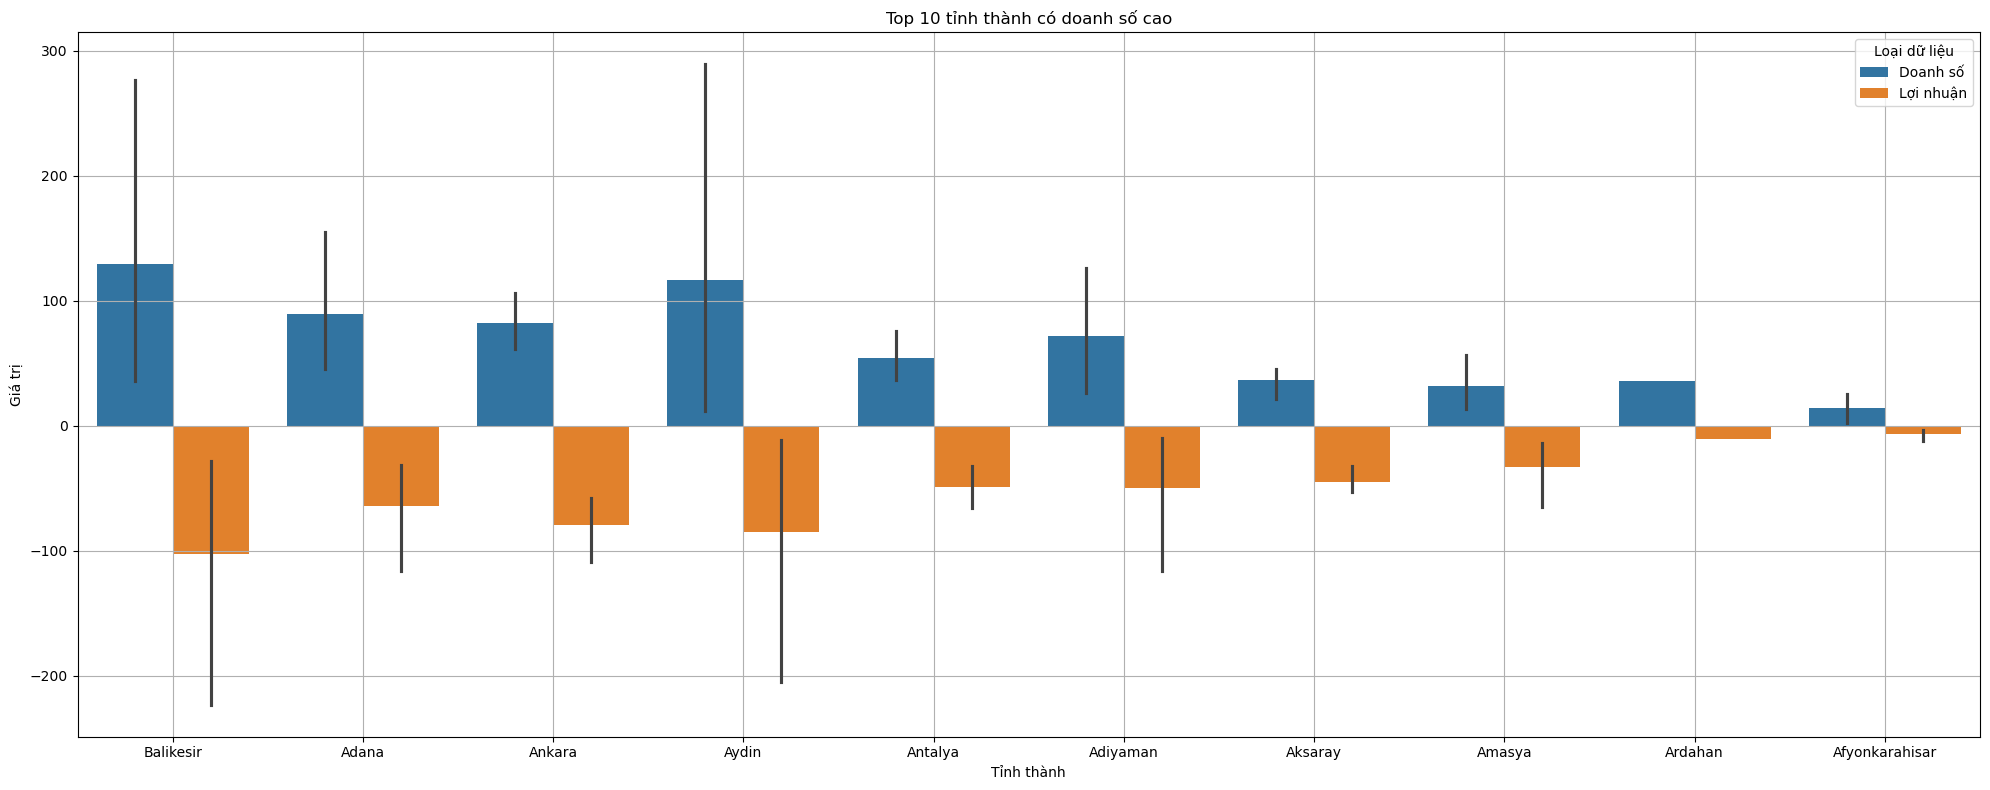

In [20]:
# Trực quan hóa 10 tỉnh thành có doanh số cao nhất
plot_df = turkey_df[['State', 'Sales', 'Profit']] # Lọc ra dữ liệu gồm các tỉnh, doanh số và lợi nhuận
out_top_10 = plot_df.groupby('State')['Sales'].mean()[10:].reset_index()['State'].tolist() # lọc ra các tỉnh trong top 10
plot_df = plot_df[~plot_df['State'].isin(out_top_10)] # chọn các tỉnh thuộc top 10 
plot_df = plot_df.melt(id_vars = ['State'], var_name = 'Metric', value_name = 'Value') # điều chỉnh data phù hợp để trực quan

# Vẽ một biểu đồ có định dạng x = 20, y = 8
plt.figure(figsize = (20, 8))

# Vẽ các cột dữ liệu doanh thu và lợi nhuận
sns.barplot(data = plot_df, x = 'State', y = 'Value', hue = 'Metric')

# Trang trí biểu đồ cột
plt.title('Top 10 tỉnh thành có doanh số cao')
plt.xlabel('Tỉnh thành')
plt.ylabel('Giá trị')
plt.grid(True)

legend_labels = ['Doanh số', 'Lợi nhuận'] # gán nhãn cụ thể cho doanh số và lợi nhuận
handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles, legend_labels, title='Loại dữ liệu')
plt.tight_layout()

# Show biểu đồ
plt.show()

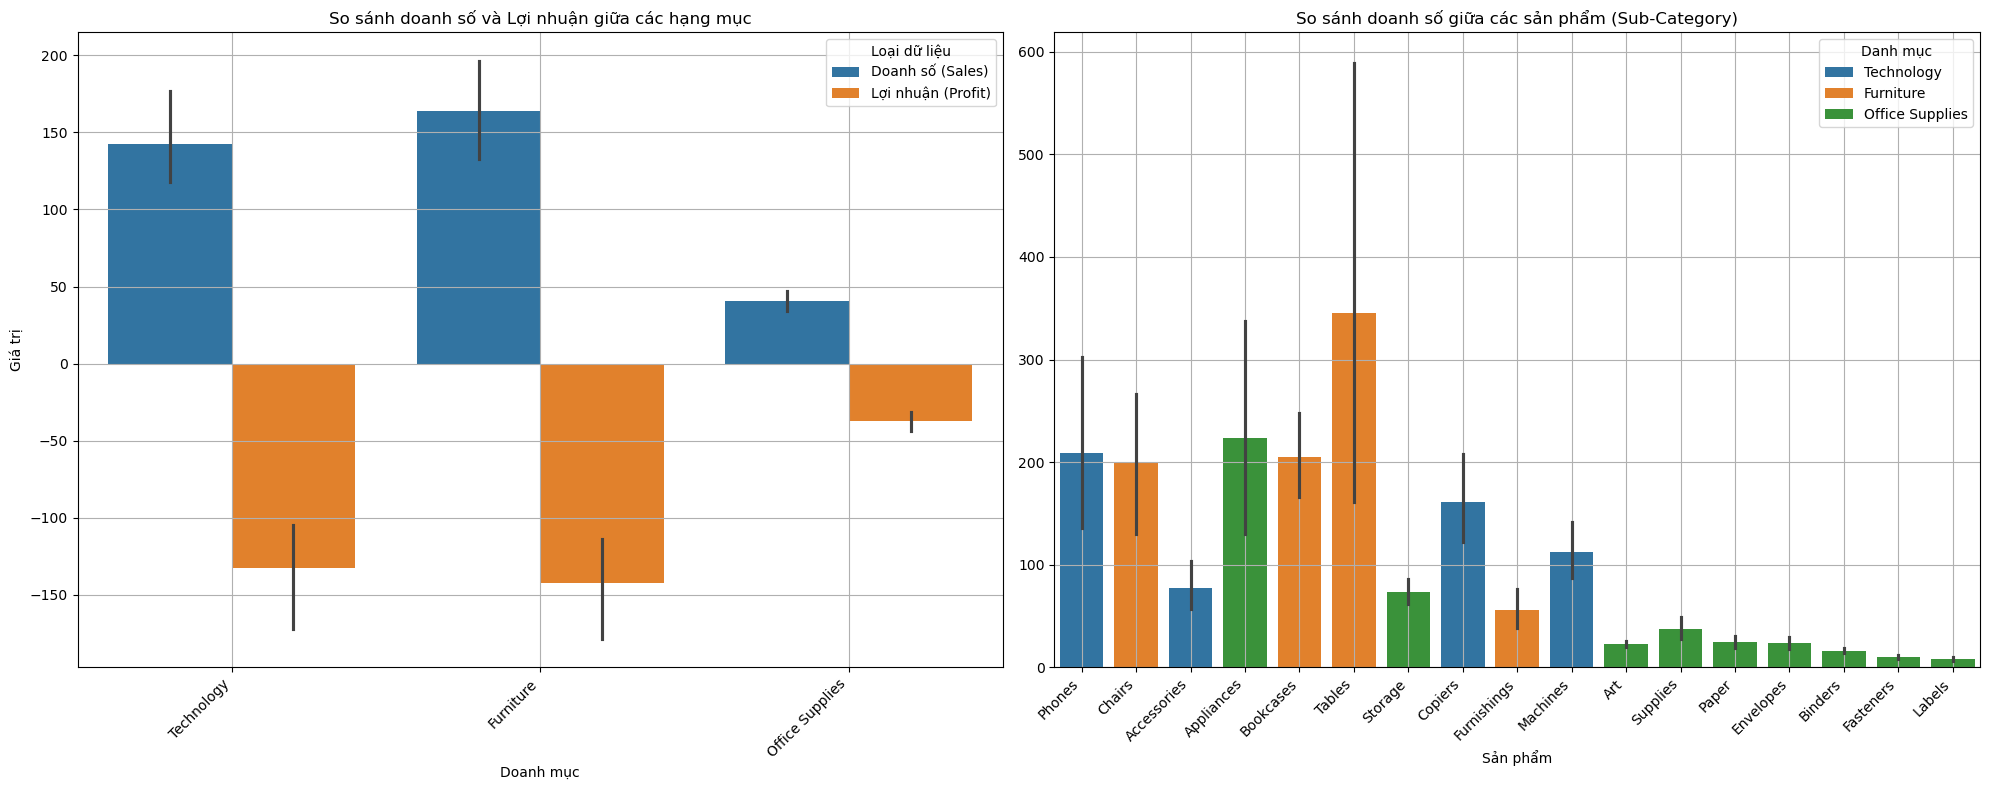

In [21]:
# Trực quan hóa doanh số và lợi nhuận của các hạng mục
category_df = turkey_df[['Category', 'Sales', 'Profit']] # lọc ra các cột cần thiết
category_df = category_df.melt(id_vars = ['Category'], var_name = 'Metric', value_name = 'Value') # điều chỉnh data phù hợp để trực quan

sub_category_df = turkey_df[['Sub-Category', 'Category', 'Sales', 'Profit']] # lọc ra các cột chứa sản phẩme

# Vẽ 2 biểu đồ nhỏ trong một biểu đồ chính có định dạng x = 20, y = 8
fig, axes = plt.subplots(1, 2, figsize = (20, 8))

# Vẽ và trang trí biểu đồ cột category
sns.barplot(data = category_df, x = 'Category', y = 'Value', hue = 'Metric',  ax = axes[0])
axes[0].set_title('So sánh doanh số và Lợi nhuận giữa các hạng mục')
axes[0].set_xlabel('Doanh mục')
axes[0].set_ylabel('Giá trị')
axes[0].grid(True)

legend_labels = ['Doanh số (Sales)', 'Lợi nhuận (Profit)']
handles, _ = axes[0].get_legend_handles_labels()
axes[0].legend(handles, legend_labels, title="Loại dữ liệu")

# Vẽ và trang trí biểu đồ cột sub_category
sns.barplot(data = sub_category_df, x = 'Sub-Category', y = 'Sales', hue = 'Category', ax = axes[1])
axes[1].set_title('So sánh doanh số giữa các sản phẩm (Sub-Category)')
axes[1].set_xlabel('Sản phẩm')
axes[1].set_ylabel('')
axes[1].legend(title = 'Danh mục')
axes[1].grid(True)

# Quay các nhãn trên trục X một góc 45 độ
for ax in axes:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()

# Show biểu đồ
plt.show()

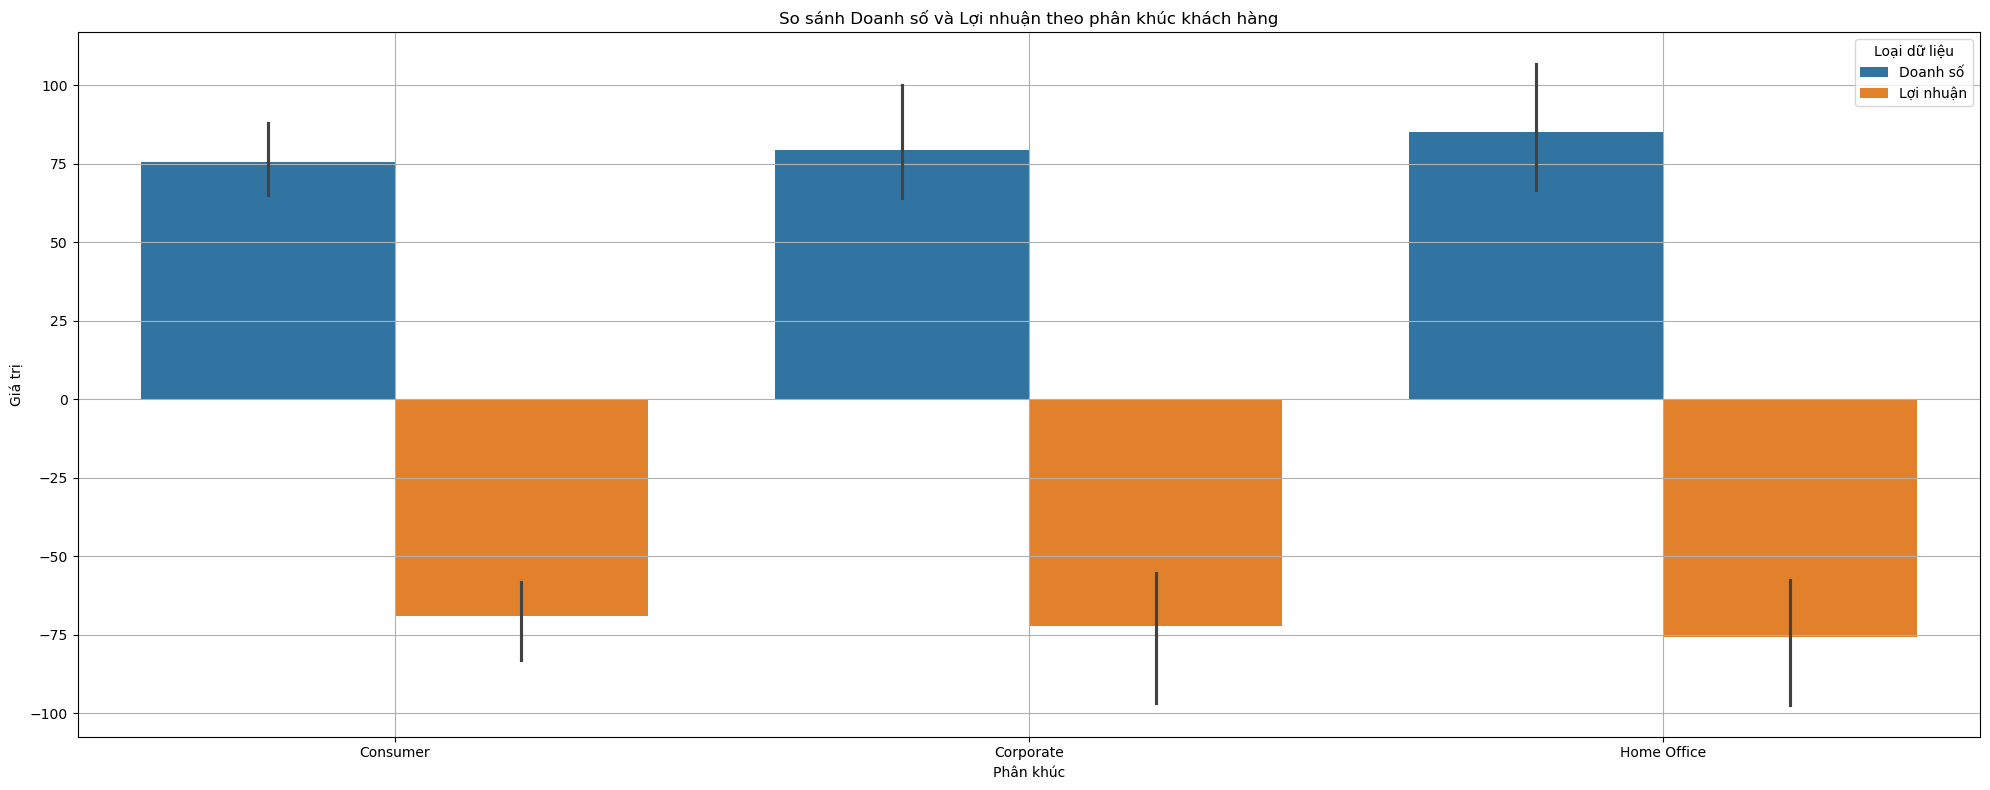

In [22]:
# Trực quan háo doanh số và lợi nhuận theo phân khúc khách hàng
segment_df = turkey_df[['Segment', 'Sales', 'Profit']] # lọc ra các cột cần thiết
segment_df = segment_df.melt(id_vars = ['Segment'], var_name = 'Metric', value_name = 'Value') # điều chỉnh data phù hợp để trực quan

# Vẽ một biểu đồ có định dạng x = 20, y = 8
plt.figure(figsize = (20, 8))

# Vẽ các cột dữ liệu doanh số và lợi nhuận segment
sns.barplot(data = segment_df, x = 'Segment', y = 'Value', hue = 'Metric')

# Trang trí biểu đồ
plt.title('So sánh Doanh số và Lợi nhuận theo phân khúc khách hàng')
plt.xlabel('Phân khúc')
plt.ylabel('Giá trị')
plt.grid(True)
 
legend_labels = ['Doanh số', 'Lợi nhuận'] # gán nhãn cụ thể cho lợi nhuận và doanh thu
handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles, legend_labels, title='Loại dữ liệu')

plt.tight_layout()

# Show biểu đồ
plt.show()

---

### Câu 4

In [23]:
# Phân tích tổng quan dữ liệu để đưa ra giải pháp kinh doanh
summary_stats = turkey_df[['Sales', 'Profit', 'Shipping Cost', 'Processing Time']].describe()

turkey_df['Profit Ratio'] = turkey_df['Profit'] / turkey_df['Sales']
profit_by_category = turkey_df.groupby('Category')['Profit Ratio'].mean().sort_values(ascending=False)

processing_by_ship_mode = turkey_df.groupby('Ship Mode')['Processing Time'].mean().sort_values()

In [24]:
summary_stats

,Sales,Profit,Shipping Cost,Processing Time
count,1378.000000,1378.000000,1378.000000,1378.000000
mean,78.743033,-71.442148,8.464557,3.957184
std,172.809813,184.849580,20.624969,1.726060
min,1.550000,-4088.380000,0.020000,0.000000
25%,11.065000,-67.425000,0.910000,3.000000
50%,24.615000,-22.610000,2.530000,4.000000
75%,79.370000,-8.372500,7.562500,5.000000
max,3085.340000,-0.700000,363.730000,7.000000


In [25]:
profit_by_category, processing_by_ship_mode

(Category
 Furniture         -0.873424
 Office Supplies   -0.875951
 Technology        -0.916236
 Name: Profit Ratio, dtype: float64,
 Ship Mode
 Same Day          0.000000
 First Class       2.202020
 Second Class      3.355932
 Standard Class    4.990087
 Name: Processing Time, dtype: float64)

---

Những điểm chính rút ra từ dữ liệu:

1. Toàn bộ danh mục đều lỗ

- Lợi nhuận trung bình của tất cả danh mục đều âm, với công nghệ (-91.6%), văn phòng phẩm (-87.6%) và nội thất (-87.3%).
- Điều này có thể do giá bán chưa hợp lý hoặc chi phí vận hành quá cao. Doanh nghiệp cần xem xét lại chiến lược giá và kiểm soát chi phí tốt hơn.

2. Thời gian xử lý đơn hàng thay đổi theo phương thức vận chuyển

- Đơn hàng Same Day được xử lý ngay lập tức (0 ngày).
- First Class (2.2 ngày) và Second Class (3.36 ngày) nhanh hơn so với Standard Class (4.99 ngày).
- Cần kiểm tra xem thời gian giao hàng có ảnh hưởng đến sự hài lòng của khách hàng hay không và có thể tối ưu hơn nữa.

3. Chi phí vận chuyển dao động mạnh

- Trung bình khoảng 8.46, nhưng có những đơn lên đến 363.73, cho thấy một số đơn hàng có chi phí vận chuyển rất cao.
- Cần phân tích kỹ hơn xem những đơn này thuộc khu vực nào, có đặc điểm gì và có cách nào tối ưu để giảm chi phí không.

---

Đề xuất giải pháp kinh doanh:

1. Tối ưu danh mục sản phẩm

- Cắt giảm hoặc điều chỉnh những sản phẩm có lợi nhuận quá thấp, đặc biệt là nhóm công nghệ.
- Tìm ra các sản phẩm bán chạy nhưng lợi nhuận thấp để xem xét tăng giá hoặc giảm chi phí sản xuất/nhập hàng.

2. Giảm chi phí vận chuyển

- Linh hoạt lựa chọn phương thức vận chuyển theo giá trị đơn hàng:
    + Đơn hàng nhỏ → ưu tiên Standard Class để tiết kiệm chi phí.
    + Đơn hàng lớn hoặc khách VIP → có thể miễn phí First Class để nâng cao trải nghiệm.
- Phân tích khu vực có chi phí vận chuyển cao để thương lượng lại với đơn vị vận chuyển hoặc tìm phương án tối ưu hơn.

3. Tăng tốc độ xử lý đơn hàng

- Kiểm tra xem có điểm nghẽn nào trong quy trình xử lý không và khắc phục.
- Nếu cần, đầu tư vào hệ thống tự động hóa kho để rút ngắn thời gian xử lý đơn hàng.

---